## Objetivo del proyecto
Este notebook desarrolla un modelo de Customer Lifetime Value (CLV) para predecir el gasto futuro de clientes utilizando variables históricas de comportamiento, canales y divisiones de compra.

In [1]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Carga de archivos
Se cargan y extraen los archivos comprimidos que contienen la información transaccional del retail.

In [2]:
#Lectura en google colab
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving sample_trans.zip to sample_trans (1).zip


dict_keys(['sample_trans (1).zip'])

In [3]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import zipfile
 # toma el primer archivo subido
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
   # lista los archivos dentro del ZIP
    print(z.namelist())


['sample_trans.csv']


In [4]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall()    # extrae en el directorio actual

## Lectura del dataset
Se carga el archivo CSV principal y se revisa la dimensión inicial del dataset.

In [5]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
df = pd.read_csv("sample_trans.csv", low_memory=False, encoding="utf-8")
print("Shape original:", df.shape)

Shape original: (4101885, 8)


## Exploración inicial
Se inspeccionan columnas y registros para validar estructura y calidad de datos.

In [6]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
print("Primeras columnas:")
print(df.columns[:40].tolist())

print("\nPrimeras filas:")
display(df.head())

Primeras columnas:
['fecha_de_transaccion', 'canal_de_compra', 'division', 'sku_producto', 'cliente_unico_id', 'orden_de_venta', 'monto_bruto', 'monto_neto']

Primeras filas:


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


In [33]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
fecha_mim = df["fecha_de_transaccion"].min()
print(fecha_mim)

2024-09-01 00:00:00


In [36]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
fecha_mim = df["fecha_de_transaccion"].min()
print("fecha min:", fecha_mim)
fecha_max= df["fecha_de_transaccion"].max()
print("fecha max:", fecha_max)

fecha min: 2024-09-01 00:00:00
fecha max: 2025-08-11 00:00:00


## Ingeniería de variables RFM
Se construyen variables de Recency, Frequency y Monetary para resumir el comportamiento de compra de cada cliente.

In [7]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import pandas as pd

# 1. Convertir fecha
df["fecha_de_transaccion"] = pd.to_datetime(df["fecha_de_transaccion"])

# 2. Fecha máxima del dataset
fecha_max = df["fecha_de_transaccion"].max()

# 3. Crear variables RFM por cliente
rfm = df.groupby("cliente_unico_id").agg(
    recency=("fecha_de_transaccion", lambda x: (fecha_max - x.max()).days),
    frequency=("orden_de_venta", "nunique"),
    monetary_total=("monto_neto", "sum"),
    ticket_promedio=("monto_neto", "mean"),
    ultima_compra=("fecha_de_transaccion", "max")
).reset_index()

# 4. Ver resultado
rfm.head()

/tmp/ipykernel_1694/3160784961.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["fecha_de_transaccion"] = pd.to_datetime(df["fecha_de_transaccion"])


,cliente_unico_id,recency,frequency,monetary_total,ticket_promedio,ultima_compra
0,000005d043269af46202a43748865e64,336,4,27747.00,6936.75,2024-09-09
1,000005f709693df2d048c8396c1e6162,68,2,4509.84,1503.28,2025-06-04
2,000008fe7c2d1f99f5dae8afb4235c8c,175,1,1438.00,719.00,2025-02-17
3,0000444fcca40a6242c5279210021108,210,1,585.86,585.86,2025-01-13
4,00004cfade0c9f7a491c7472051a5673,176,1,2327.59,2327.59,2025-02-16


In [8]:
# Clientes que compraron más recientemente
rfm.sort_values("recency").head()

# Clientes con más compras
rfm.sort_values("frequency", ascending=False).head()

# Clientes con mayor gasto
rfm.sort_values("monetary_total", ascending=False).head()

,cliente_unico_id,recency,frequency,monetary_total,ticket_promedio,ultima_compra
569549,bd4c7f60a9aff2be84313eb03c972b02,0,11189,1.283652e+08,9244.882911,2025-08-11
713079,ecc7ce31b24fddf7f51d73611d1f989d,44,14,1.354107e+07,796533.652353,2025-06-28
23812,07d8bfe05b95805277181bf1b9232285,31,22,1.292875e+07,587670.454545,2025-07-11
251549,53b695482ddca2c8f8fc3ae23709e16e,0,637,1.196155e+07,13748.903529,2025-08-11
228167,4bf3f0b51b2ed7ce05300cd6059dd7d3,0,1154,1.054989e+07,8140.350332,2025-08-11


In [9]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
df.head(10)

,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,2025-07-30,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,2024-11-18,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,2024-09-03,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2025-02-01,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,2024-12-29,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00
5,2025-05-23,Palacio de Hierro,CABALLEROS,38698390,8d7abae8139e9d56e3dc658106b6d17a,20250523_1000_281_222,719.00,719.00
6,2025-02-01,E Commerce,JUGUETERIA,44348344,087f191014d2dee634994fbc60a7f2ef,Sites-palacio-MX-Site.5010192795,499.00,430.17
7,2025-06-15,Palacio de Hierro,INFANTILES,44342196,6c9ea54b12ba01df5bb4264e324cfc42,20250615_1004_221_3915,1295.00,1295.00
8,2024-10-03,Palacio de Hierro,HOGAR,42673703,ead8ef592cc2fba34142f1a749395640,20241003_1006_275_8991.0,11564.00,11564.00
9,2025-06-03,Palacio de Hierro,MARCAS PROPIAS,44245942,2bd0c2ed4c2f158620dadc95ab312d59,20250603_1004_222_2525,919.00,919.00


In [10]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
df["year_month"] = df["fecha_de_transaccion"].dt.to_period("M")

In [11]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
df.head(10)

,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto,year_month
0,2025-07-30,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00,2025-07
1,2024-11-18,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00,2024-11
2,2024-09-03,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00,2024-09
3,2025-02-01,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32,2025-02
4,2024-12-29,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00,2024-12
5,2025-05-23,Palacio de Hierro,CABALLEROS,38698390,8d7abae8139e9d56e3dc658106b6d17a,20250523_1000_281_222,719.00,719.00,2025-05
6,2025-02-01,E Commerce,JUGUETERIA,44348344,087f191014d2dee634994fbc60a7f2ef,Sites-palacio-MX-Site.5010192795,499.00,430.17,2025-02
7,2025-06-15,Palacio de Hierro,INFANTILES,44342196,6c9ea54b12ba01df5bb4264e324cfc42,20250615_1004_221_3915,1295.00,1295.00,2025-06
8,2024-10-03,Palacio de Hierro,HOGAR,42673703,ead8ef592cc2fba34142f1a749395640,20241003_1006_275_8991.0,11564.00,11564.00,2024-10
9,2025-06-03,Palacio de Hierro,MARCAS PROPIAS,44245942,2bd0c2ed4c2f158620dadc95ab312d59,20250603_1004_222_2525,919.00,919.00,2025-06


In [14]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
fecha_max = df["fecha_de_transaccion"].max()
print("La fecha máxima es:",fecha_max )

La fecha máxima es: 2025-08-11 00:00:00


In [15]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
rfm = df.groupby("cliente_unico_id").agg(

    # RECENCY
    recency=(
        "fecha_de_transaccion",
        lambda x: (fecha_max - x.max()).days
    ),

    # FREQUENCY
    frequency=(
        "orden_de_venta",
        "nunique"
    ),

    # MONETARY
    monetary_total=(
        "monto_neto",
        "sum"
    ),

    # TICKET PROMEDIO
    ticket_promedio=(
        "monto_neto",
        "mean"
    ),

    # DESVIACIÓN DE GASTO
    std_gasto=(
        "monto_neto",
        "std"
    ),

    # ÚLTIMA COMPRA
    ultima_compra=(
        "fecha_de_transaccion",
        "max"
    ),

    # PRIMERA COMPRA
    primera_compra=(
        "fecha_de_transaccion",
        "min"
    )

).reset_index()

In [16]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
rfm["antiguedad_cliente"] = (
    rfm["ultima_compra"] - rfm["primera_compra"]
).dt.days


## Features por división y canal
Se generan variables agregadas mediante tablas pivote para representar preferencias de compra.

In [17]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
division_features = pd.pivot_table(
    df,
    index="cliente_unico_id",
    columns="division",
    values="monto_neto",
    aggfunc="sum",
    fill_value=0
).reset_index()


In [18]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
canal_features = pd.pivot_table(
    df,
    index="cliente_unico_id",
    columns="canal_de_compra",
    values="monto_neto",
    aggfunc="sum",
    fill_value=0
).reset_index()

In [19]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
num_divisiones = df.groupby(
    "cliente_unico_id"
)["division"].nunique().reset_index()

num_divisiones.columns = [
    "cliente_unico_id",
    "num_divisiones"
]


In [20]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
num_canales = df.groupby(
    "cliente_unico_id"
)["canal_de_compra"].nunique().reset_index()

num_canales.columns = [
    "cliente_unico_id",
    "num_canales"
]

In [21]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
mensual = df.groupby(
    ["cliente_unico_id", "year_month"]
).agg(
    gasto_mes=("monto_neto", "sum")
).reset_index()

In [22]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
promedio_mensual = mensual.groupby(
    "cliente_unico_id"
).agg(
    avg_gasto_mensual=("gasto_mes", "mean")
).reset_index()

In [23]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
max_gasto_mensual = mensual.groupby(
    "cliente_unico_id"
).agg(
    max_gasto_mensual=("gasto_mes", "max")
).reset_index()

In [24]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
min_gasto_mensual = mensual.groupby(
    "cliente_unico_id"
).agg(
    min_gasto_mensual=("gasto_mes", "min")
).reset_index()

In [25]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
variabilidad_gasto = mensual.groupby(
    "cliente_unico_id"
).agg(
    std_gasto_mensual=("gasto_mes", "std")
).reset_index()

## Construcción del dataset final
Se integran todas las variables en una sola tabla para modelado.

In [26]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
features = (
    rfm
    .merge(division_features,
           on="cliente_unico_id",
           how="left")
    .merge(canal_features,
           on="cliente_unico_id",
           how="left")
    .merge(num_divisiones,
           on="cliente_unico_id",
           how="left")
    .merge(num_canales,
           on="cliente_unico_id",
           how="left")
    .merge(promedio_mensual,
           on="cliente_unico_id",
           how="left")
    .merge(max_gasto_mensual,
           on="cliente_unico_id",
           how="left")
    .merge(min_gasto_mensual,
           on="cliente_unico_id",
           how="left")
    .merge(variabilidad_gasto,
           on="cliente_unico_id",
           how="left")
)

In [27]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
print(features.shape)

features.head()

(770941, 46)


,cliente_unico_id,recency,frequency,monetary_total,ticket_promedio,std_gasto,ultima_compra,primera_compra,antiguedad_cliente,BELLEZA,...,E Commerce,La BPH,Outlets,Palacio de Hierro,num_divisiones,num_canales,avg_gasto_mensual,max_gasto_mensual,min_gasto_mensual,std_gasto_mensual
0,000005d043269af46202a43748865e64,336,4,27747.00,6936.75,11400.318720,2024-09-09,2024-09-05,4,0.00,...,2269.00,0.0,0.0,25478.0,4,2,27747.00,27747.00,27747.00,NaN
1,000005f709693df2d048c8396c1e6162,68,2,4509.84,1503.28,496.024710,2025-06-04,2025-05-30,5,0.00,...,4509.84,0.0,0.0,0.0,2,1,2254.92,2720.18,1789.66,657.977002
2,000008fe7c2d1f99f5dae8afb4235c8c,175,1,1438.00,719.00,418.607214,2025-02-17,2025-02-17,0,0.00,...,0.00,0.0,0.0,1438.0,1,1,1438.00,1438.00,1438.00,NaN
3,0000444fcca40a6242c5279210021108,210,1,585.86,585.86,NaN,2025-01-13,2025-01-13,0,0.00,...,585.86,0.0,0.0,0.0,1,1,585.86,585.86,585.86,NaN
4,00004cfade0c9f7a491c7472051a5673,176,1,2327.59,2327.59,NaN,2025-02-16,2025-02-16,0,2327.59,...,2327.59,0.0,0.0,0.0,1,1,2327.59,2327.59,2327.59,NaN


In [28]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
features.isnull().sum()

,0
cliente_unico_id,0
recency,0
frequency,0
monetary_total,0
ticket_promedio,0
std_gasto,270274
ultima_compra,0
primera_compra,0
antiguedad_cliente,0
BELLEZA,10510


In [29]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
features = features.fillna(0)

In [30]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
features.shape

(770941, 46)

In [37]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
fecha_corte = "2025-06-01"

In [38]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
historico = df[
    df["fecha_de_transaccion"] < fecha_corte
]

futuro = df[
    df["fecha_de_transaccion"] >= fecha_corte
]

In [39]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
fecha_max_historico = historico[
    "fecha_de_transaccion"
].max()

rfm = historico.groupby(
    "cliente_unico_id"
).agg(

    recency=(
        "fecha_de_transaccion",
        lambda x: (
            fecha_max_historico - x.max()
        ).days
    ),

    frequency=(
        "orden_de_venta",
        "nunique"
    ),

    monetary_total=(
        "monto_neto",
        "sum"
    ),

    ticket_promedio=(
        "monto_neto",
        "mean"
    )

).reset_index()

In [40]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
target = futuro.groupby(
    "cliente_unico_id"
).agg(
    target_clv=("monto_neto", "sum")
).reset_index()

In [41]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo = rfm.merge(
    target,
    on="cliente_unico_id",
    how="left"
)

In [42]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo["target_clv"] = (
    dataset_modelo["target_clv"]
    .fillna(0)
)

In [43]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo.isnull().sum()

,0
cliente_unico_id,0
recency,0
frequency,0
monetary_total,0
ticket_promedio,0
target_clv,0


In [56]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo.dtypes

,0
recency,int64
frequency,int64
monetary_total,float64
ticket_promedio,float64
target_clv,float64


In [51]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo = dataset_modelo.drop(
    columns=[
        "cliente_unico_id",
        "ultima_compra",
        "primera_compra"
    ],
    errors="ignore"
)

In [52]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo.head(10)

,recency,frequency,monetary_total,ticket_promedio,target_clv
0,264,4,27747.00,6936.75,0.00
1,1,1,1789.66,1789.66,2720.18
2,103,1,1438.00,719.00,0.00
3,138,1,585.86,585.86,0.00
4,104,1,2327.59,2327.59,0.00
5,267,1,2319.00,2319.00,0.00
6,113,1,4309.48,4309.48,0.00
7,104,2,5715.52,2857.76,0.00
8,15,5,8529.00,1705.80,0.00
9,33,7,8244.00,1030.50,0.00


In [53]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
X = dataset_modelo.drop(
    columns=["target_clv"]
)

y = dataset_modelo["target_clv"]

In [58]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
print(X.shape)
print(y.shape)

(703214, 4)
(703214,)


In [59]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

Primer Modelo

## Entrenamiento de modelos
Se entrenan modelos de LightGBM, XGBoost y Redes Neuronales.

In [60]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 849
[LightGBM] [Info] Number of data points in the train set: 562571, number of used features: 4
[LightGBM] [Info] Start training from score 1796.718688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMRegressor(learning_rate=0.05, max_depth=8, n_estimators=300,
              random_state=42)

In [61]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
preds_lgbm = lgbm_model.predict(X_test)

In [64]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, preds_lgbm)

mse = mean_squared_error(y_test, preds_lgbm)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, preds_lgbm)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2486.5522625830913
RMSE: 16232.771079892478
R2: 0.13808191235819167


validación


In [65]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo["target_clv"].describe()

,target_clv
count,7.032140e+05
mean,1.800886e+03
std,2.426607e+04
min,-4.306870e+05
25%,0.000000e+00
50%,0.000000e+00
75%,3.820000e+02
max,1.562817e+07


## Análisis exploratorio de datos
Se analizan distribuciones, outliers y sesgo del target.

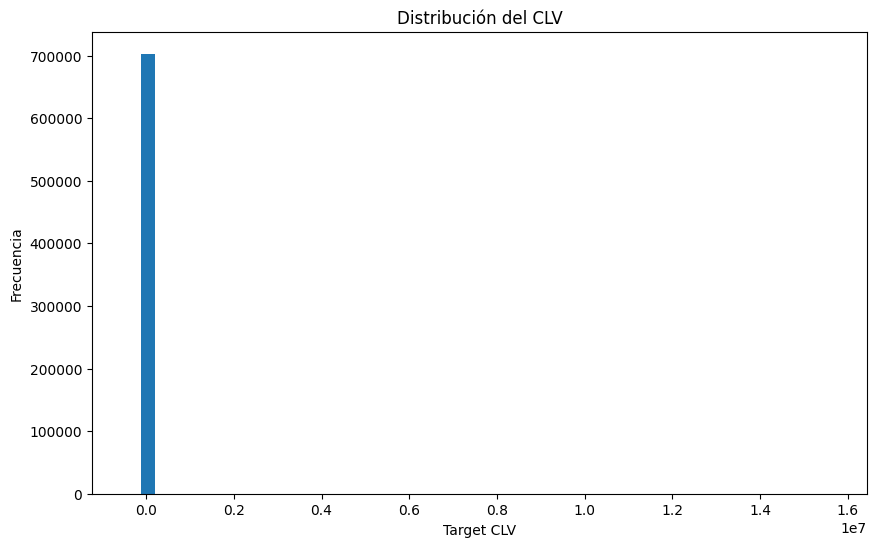

In [66]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    dataset_modelo["target_clv"],
    bins=50
)

plt.title("Distribución del CLV")
plt.xlabel("Target CLV")
plt.ylabel("Frecuencia")

plt.show()

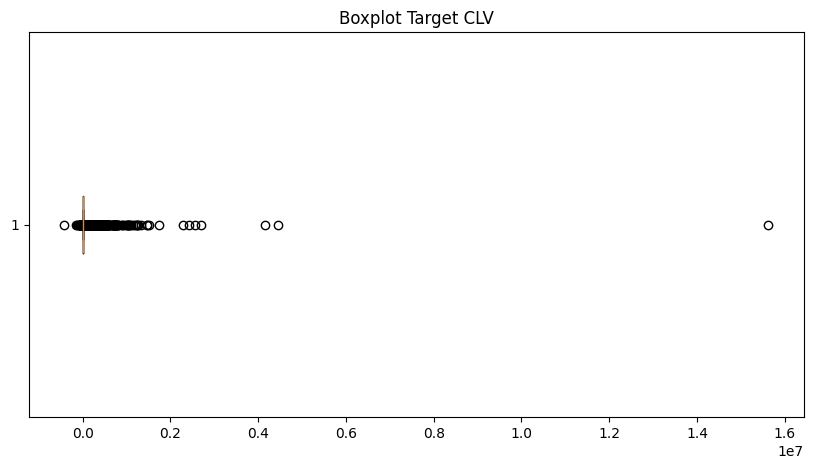

In [67]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
plt.figure(figsize=(10,5))

plt.boxplot(
    dataset_modelo["target_clv"],
    vert=False
)

plt.title("Boxplot Target CLV")

plt.show()

In [68]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
Q1 = dataset_modelo["target_clv"].quantile(0.25)

Q3 = dataset_modelo["target_clv"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.0
Q3: 382.0
IQR: 382.0
Lower Bound: -573.0
Upper Bound: 955.0


In [69]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
outliers = dataset_modelo[
    (dataset_modelo["target_clv"] < lower_bound) |
    (dataset_modelo["target_clv"] > upper_bound)
]

In [70]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
print("Número de outliers:")

print(outliers.shape[0])

Número de outliers:
148848


In [71]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
porcentaje_outliers = (
    outliers.shape[0] /
    dataset_modelo.shape[0]
) * 100

print(
    f"Porcentaje de outliers: {porcentaje_outliers:.2f}%"
)

Porcentaje de outliers: 21.17%


In [72]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
outliers.sort_values(
    "target_clv",
    ascending=False
).head(10)

,recency,frequency,monetary_total,ticket_promedio,target_clv
519548,0,9237,1.127370e+08,9899.633463,15628173.34
229519,0,353,7.517936e+06,16559.331432,4443609.60
66159,0,321,5.699288e+06,14803.346130,4147123.46
602287,0,180,3.778711e+06,16944.890359,2704491.26
696249,1,19,3.560891e+05,11486.744839,2554004.11
178274,0,66,1.185553e+06,13785.498837,2431388.13
624651,1,117,2.167306e+06,16054.120593,2294301.91
694141,0,229,3.419650e+06,11592.032271,1741576.10
820,1,411,6.083917e+06,13225.905674,1505078.24
497289,0,7,1.510675e+05,16785.281111,1472947.35


In [73]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
variables_numericas = [
    "monetary_total",
    "ticket_promedio",
    "frequency",
    "target_clv"
]

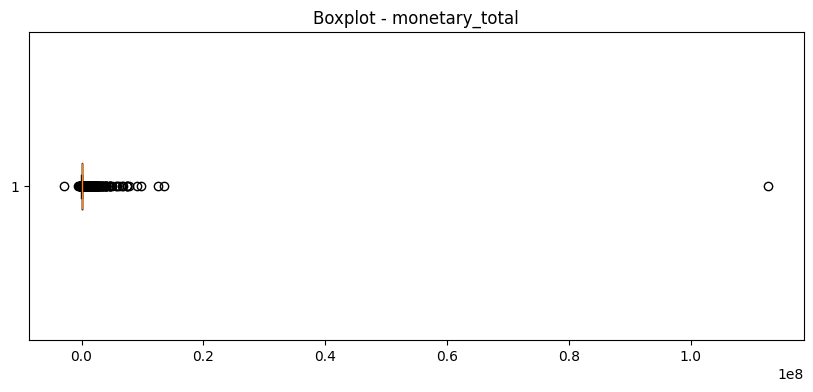

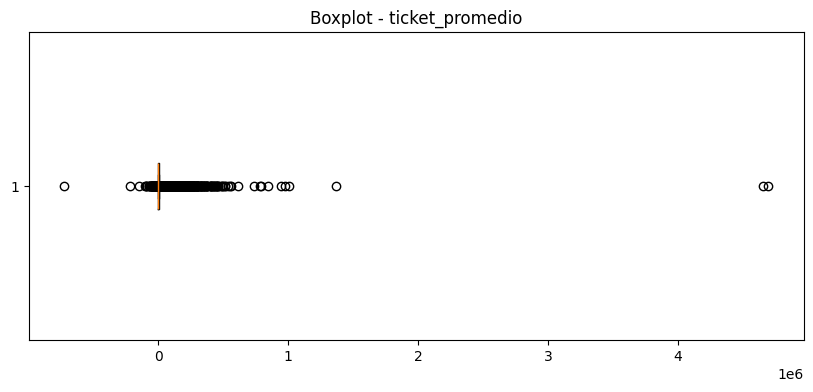

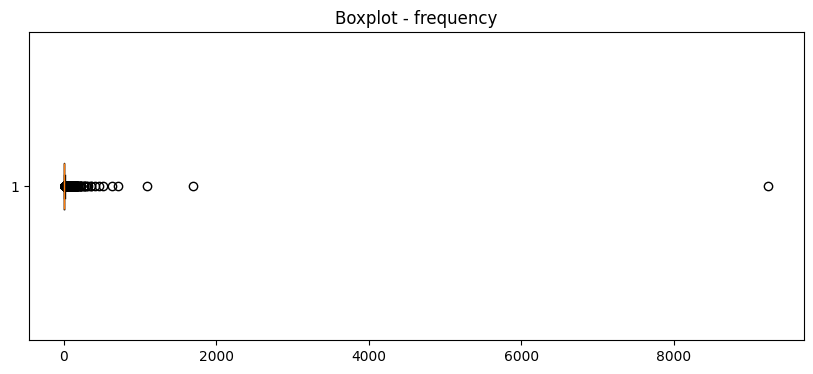

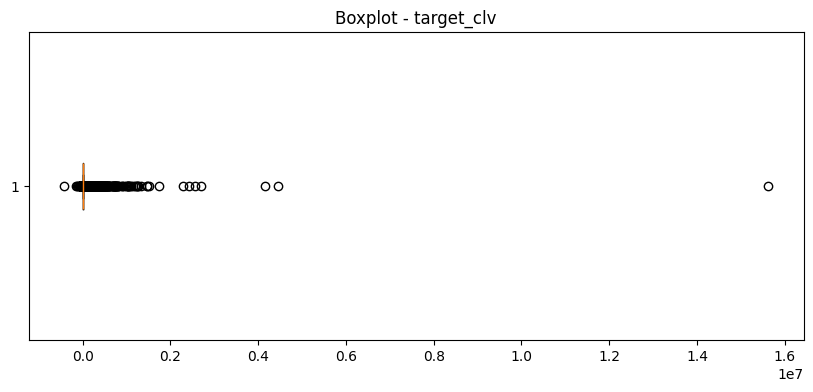

In [74]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
for col in variables_numericas:

    plt.figure(figsize=(10,4))

    plt.boxplot(
        dataset_modelo[col],
        vert=False
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

In [75]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
for col in variables_numericas:

    skewness = dataset_modelo[col].skew()

    print(f"{col}: {skewness}")

monetary_total: 637.3988289622995
ticket_promedio: 176.45519165856794
frequency: 547.8183934662819
target_clv: 408.04636511679246


In [76]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo["target_log"] = np.log1p(
    dataset_modelo["target_clv"]
)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Validación de valores negativos

In [78]:
# Valores negativos
dataset_modelo[
    dataset_modelo["target_clv"] < 0
].shape

(2881, 6)

In [79]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo[
    dataset_modelo["target_clv"] < 0
].head()

,recency,frequency,monetary_total,ticket_promedio,target_clv,target_log
219,5,23,148375.24,5706.740000,-2808.45,NaN
245,51,1,490.00,490.000000,-180.00,NaN
301,15,20,26338.00,1197.181818,-11649.00,NaN
500,0,8,9152.38,704.029231,-22.00,NaN
576,56,9,13761.55,764.530556,-57.76,NaN


In [80]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo = dataset_modelo[
    dataset_modelo["target_clv"] >= 0
]

In [81]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.


dataset_modelo["target_log"] = np.log1p(
    dataset_modelo["target_clv"]
)

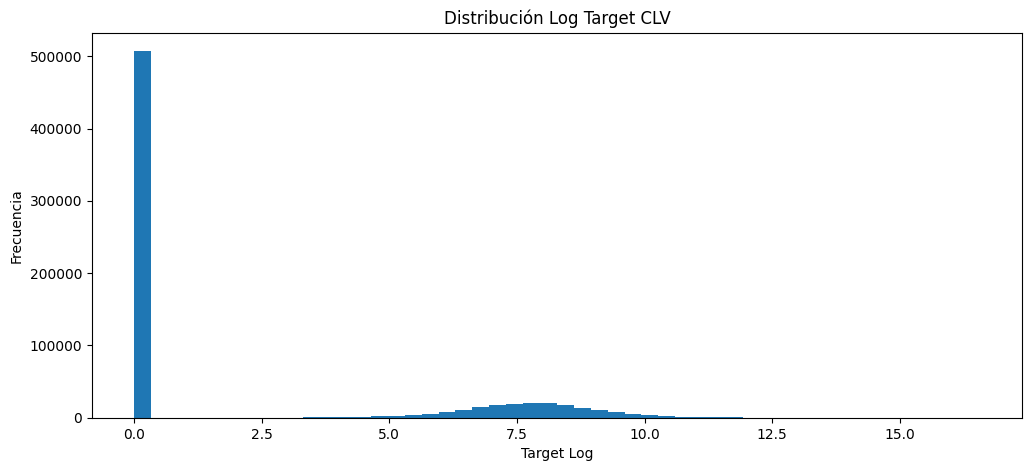

In [82]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.hist(
    dataset_modelo["target_log"],
    bins=50
)

plt.title("Distribución Log Target CLV")

plt.xlabel("Target Log")
plt.ylabel("Frecuencia")

plt.show()

In [83]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
np.isinf(dataset_modelo["target_log"]).sum()

np.int64(0)

In [84]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
dataset_modelo["target_log"].isnull().sum()

np.int64(0)

In [85]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
clientes_sin_recompra = (
    dataset_modelo["target_clv"] == 0
).mean() * 100

print(
    f"Clientes sin recompra: {clientes_sin_recompra:.2f}%"
)

Clientes sin recompra: 72.38%


In [86]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
print(
    "Skewness original:",
    dataset_modelo["target_clv"].skew()
)

print(
    "Skewness log:",
    dataset_modelo["target_log"].skew()
)

Skewness original: 407.9027941127121
Skewness log: 1.1419803703713811


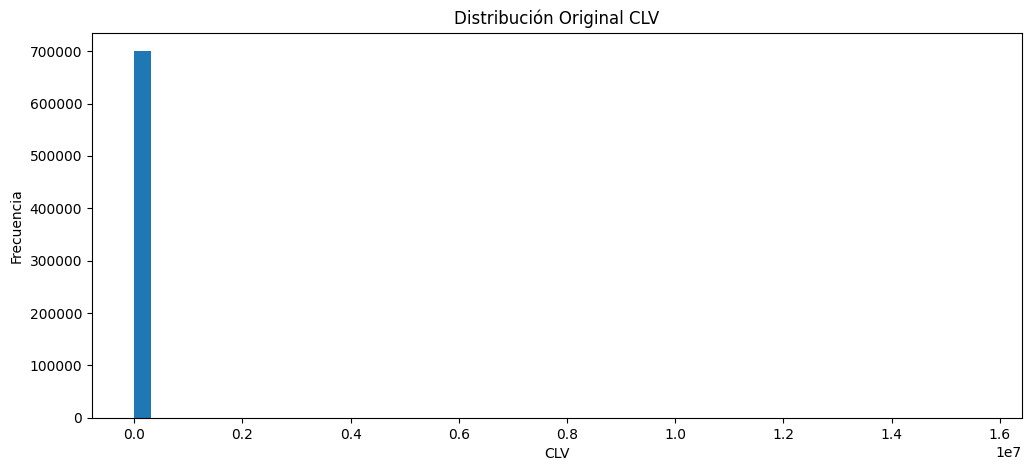

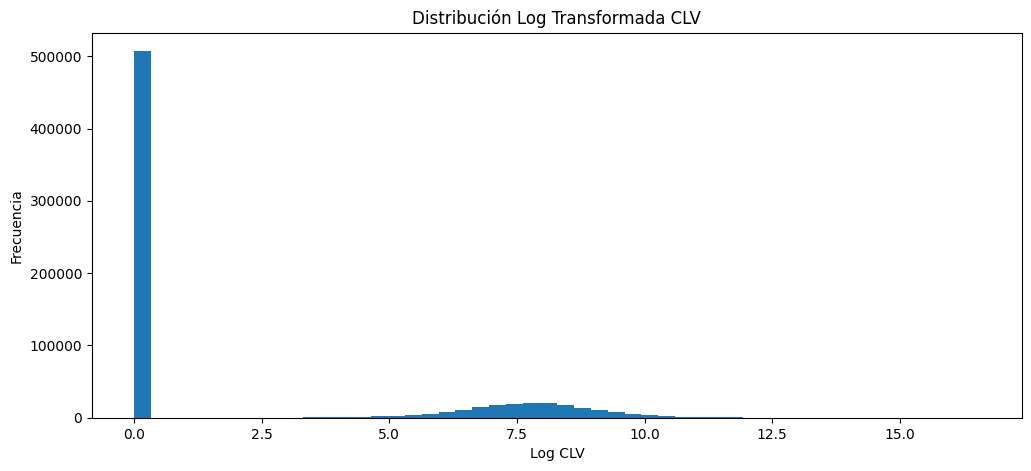

In [87]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import matplotlib.pyplot as plt

# ORIGINAL
plt.figure(figsize=(12,5))

plt.hist(
    dataset_modelo["target_clv"],
    bins=50
)

plt.title("Distribución Original CLV")

plt.xlabel("CLV")
plt.ylabel("Frecuencia")

plt.show()

# LOG
plt.figure(figsize=(12,5))

plt.hist(
    dataset_modelo["target_log"],
    bins=50
)

plt.title("Distribución Log Transformada CLV")

plt.xlabel("Log CLV")
plt.ylabel("Frecuencia")

plt.show()

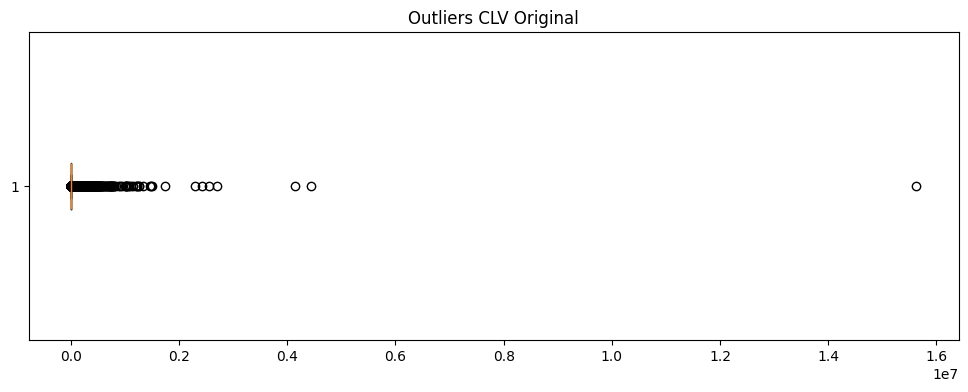

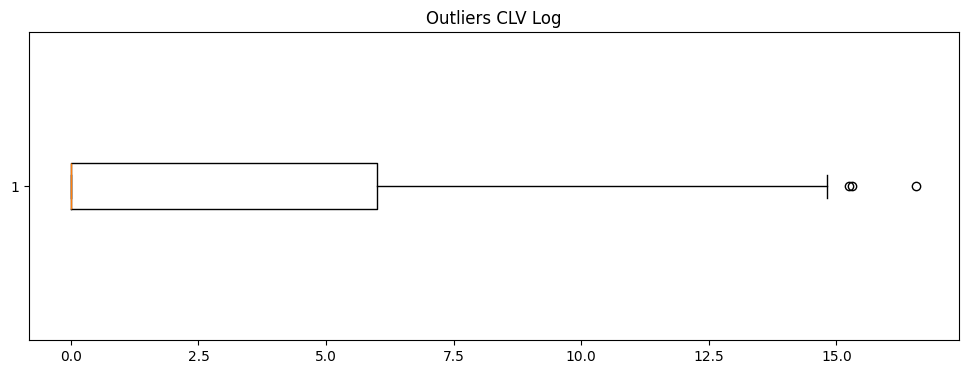

In [88]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
plt.figure(figsize=(12,4))

plt.boxplot(
    dataset_modelo["target_clv"],
    vert=False
)

plt.title("Outliers CLV Original")

plt.show()

plt.figure(figsize=(12,4))

plt.boxplot(
    dataset_modelo["target_log"],
    vert=False
)

plt.title("Outliers CLV Log")

plt.show()

## Modelo LightGBM

In [89]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
y = dataset_modelo["target_log"]

In [90]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
X = dataset_modelo.drop(
    columns=[
        "target_clv",
        "target_log"
    ],
    errors="ignore"
)

In [91]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

In [92]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 848
[LightGBM] [Info] Number of data points in the train set: 560266, number of used features: 4
[LightGBM] [Info] Start training from score 2.133861


LGBMRegressor(learning_rate=0.05, max_depth=8, n_estimators=300,
              random_state=42)

In [93]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
preds_lgbm = lgbm_model.predict(X_test)

In [94]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    preds_lgbm
)

mse = mean_squared_error(
    y_test,
    preds_lgbm
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    preds_lgbm
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.446974556528004
RMSE: 3.139074297003379
R2: 0.21489046248898547


## Modelo  xgboost

In [95]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [96]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
preds_xgb = xgb_model.predict(X_test)

In [97]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_xgb = mean_absolute_error(
    y_test,
    preds_xgb
)

mse_xgb = mean_squared_error(
    y_test,
    preds_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(
    y_test,
    preds_xgb
)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

MAE: 2.4462765289615014
RMSE: 3.1423337468861097
R2: 0.21325918299293


Comparativo

In [98]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
comparacion = pd.DataFrame({

    "Modelo": [
        "LightGBM",
        "XGBoost"
    ],

    "MAE": [
        mae,
        mae_xgb
    ],

    "RMSE": [
        rmse,
        rmse_xgb
    ],

    "R2": [
        r2,
        r2_xgb
    ]

})

comparacion

,Modelo,MAE,RMSE,R2
0,LightGBM,2.446975,3.139074,0.214890
1,XGBoost,2.446277,3.142334,0.213259


## Modelo Red neuronal

In [99]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [100]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [102]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    verbose=1
)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 11.6106 - mae: 2.4716 - val_loss: 10.5110 - val_mae: 2.7790
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 10.2333 - mae: 2.4593 - val_loss: 10.9026 - val_mae: 2.4537
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 10.0781 - mae: 2.4489 - val_loss: 10.1257 - val_mae: 2.4377
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 10.0122 - mae: 2.4514 - val_loss: 9.8899 - val_mae: 2.5008
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.9804 - mae: 2.4509 - val_loss: 10.2333 - val_mae: 2.5077
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.9539 - mae: 2.4539 - val_loss: 9.9041 - val_mae: 2.4673
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 9.9485 - mae: 2.4540 - val_loss: 9.8828 - val_mae: 2.4473
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.9307 - mae: 2.4558 - val_loss: 10.1990 - val_mae: 2.4774
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━

In [103]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
preds_nn = model.predict(
    X_test_scaled
).flatten()

4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


In [104]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
mae_nn = mean_absolute_error(
    y_test,
    preds_nn
)

mse_nn = mean_squared_error(
    y_test,
    preds_nn
)

rmse_nn = np.sqrt(mse_nn)

r2_nn = r2_score(
    y_test,
    preds_nn
)

print("MAE:", mae_nn)
print("RMSE:", rmse_nn)
print("R2:", r2_nn)

MAE: 2.470884371166735
RMSE: 3.1417617209900937
R2: 0.21354559124556316


## Comparación final
Se comparan los modelos mediante métricas de desempeño.

In [105]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
comparacion_final = pd.DataFrame({

    "Modelo": [
        "LightGBM",
        "XGBoost",
        "Neural Network"
    ],

    "MAE": [
        mae,
        mae_xgb,
        mae_nn
    ],

    "RMSE": [
        rmse,
        rmse_xgb,
        rmse_nn
    ],

    "R2": [
        r2,
        r2_xgb,
        r2_nn
    ]

})

comparacion_final.sort_values(
    "R2",
    ascending=False
)

,Modelo,MAE,RMSE,R2
0,LightGBM,2.446975,3.139074,0.214890
2,Neural Network,2.470884,3.141762,0.213546
1,XGBoost,2.446277,3.142334,0.213259


Features

In [106]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
importance = pd.DataFrame({

    "feature": X.columns,
    "importance": lgbm_model.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
0,recency,3063
3,ticket_promedio,2183
2,monetary_total,2091
1,frequency,1663


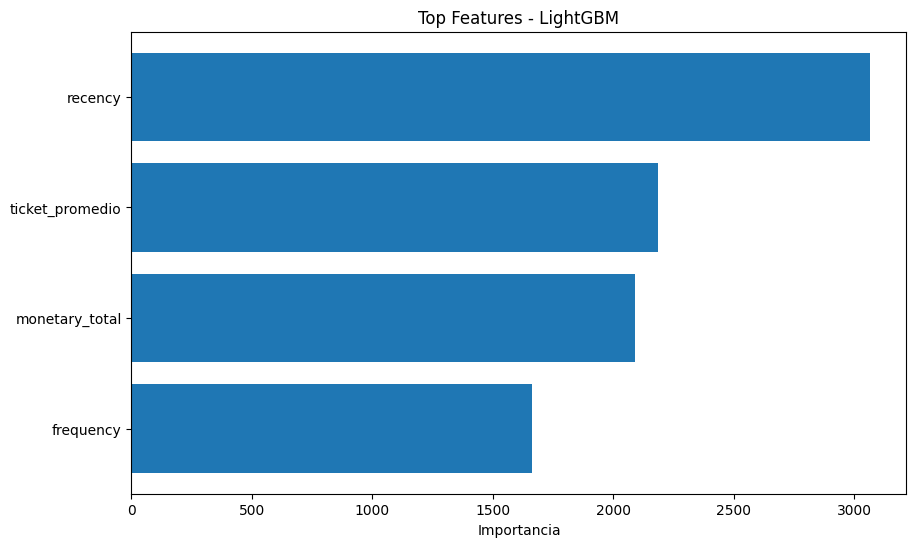

In [107]:
# Explicación: bloque de procesamiento y análisis del modelo CLV.
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Features - LightGBM")

plt.xlabel("Importancia")

plt.show()